# Heaps' Law analysis of Claude-bootstrap label vocabulary

Reads the per-experiment `features_candidate` + `features_status`
databases produced by `bin/llm_annotate_features` and plots the
cumulative-distinct-labels curve as treatments are processed in
temporal order.  Tells you whether you've collected enough
treatments to see a stable feature vocabulary, or whether more
bootstrap runs are still discovering new labels.

Three views:

1. **Raw**: distinct labels exactly as Claude returned them.
   Includes drift duplicates (`Odor` + `Odour`, `Partial_veil_microstructure`
   + `Partial_veil_(microscopic)`, etc.) — over-counts the real
   vocabulary.
2. **Canonical**: drift collapsed via a hand-edited mapping
   (`docs/feature_label_canonicalization.json`).  Closer to the
   true biological vocabulary.
3. **Hand-reviewed**: the `features_hand` DB — what the human
   reviewer actually kept.  Ground truth, when it exists.

Also reports cost / performance from the `metrics` sub-doc
(wall-clock, API latency, input/output tokens) once an
instrumented run has been done.

Re-run any time after a fresh `bin/llm_annotate_features` pass.

## Setup

In [1]:
# Path setup so the notebook can import skol modules.
import sys
from pathlib import Path
# Walk up from CWD until we find the skol repo root
# (identified by the bin/env_config.py marker).  Robust
# to the notebook being in jupyter/, notebooks/, or any
# other subdirectory.
_p = Path.cwd().resolve()
while not (_p / 'bin' / 'env_config.py').exists():
    if _p == _p.parent:  # reached filesystem root
        raise RuntimeError(
            f'could not find skol repo root from {Path.cwd()!r}'
        )
    _p = _p.parent
SKOL_ROOT = _p
sys.path.insert(0, str(SKOL_ROOT))
sys.path.insert(0, str(SKOL_ROOT / 'bin'))

import json
from collections import defaultdict, Counter
from typing import Any, Dict, List, Optional, Tuple

import couchdb
import matplotlib.pyplot as plt
import numpy as np

# Use skol's env_config so the connection settings match what the
# CLI tools use (no need to duplicate the URL / credentials here).
from env_config import get_env_config

# --- Configuration: edit these to retarget the notebook ---
EXPERIMENT = 'production_v4'
CANONICALIZATION_PATH = (
    SKOL_ROOT / 'docs' / 'feature_label_canonicalization.json'
)
# ----------------------------------------------------------

class _Args:
    pass
_args = _Args()
_args.experiment = EXPERIMENT
config = get_env_config(cli_args=_args)
server = couchdb.Server(config['couchdb_url'])
server.resource.credentials = (
    config['couchdb_username'], config['couchdb_password'],
)
print(f'Connected to {config["couchdb_url"]}; experiment = {EXPERIMENT!r}')

Connected to http://localhost:5984; experiment = 'production_v4'


## Load annotations + status docs

Loads everything for the experiment in two queries — annotations
(for the Heaps' Law curve) and status docs (for the metrics).
Treatment order comes from the annotations' `created_at` (set once
per Claude call, shared by all annotations from that call).

In [2]:
def load_candidate_annotations(experiment: str) -> List[Dict[str, Any]]:
    # Fallback naming convention; matches bin/llm_annotate_features.
    db_name = f'skol_exp_{experiment}_02_50_features_candidate'
    if db_name not in server:
        raise RuntimeError(
            f'{db_name!r} not found — run bin/llm_annotate_features first'
        )
    rows = server[db_name].view('_all_docs', include_docs=True).rows
    return [dict(r.doc) for r in rows if r.doc is not None]


def load_status_docs(experiment: str) -> List[Dict[str, Any]]:
    db_name = f'skol_exp_{experiment}_02_50_features_status'
    if db_name not in server:
        return []  # pre-Design-Y data; downstream cells degrade gracefully
    rows = server[db_name].view('_all_docs', include_docs=True).rows
    return [dict(r.doc) for r in rows if r.doc is not None]


def load_hand_annotations(experiment: str) -> List[Dict[str, Any]]:
    # Optional: features_hand may not exist yet.  Downstream cells
    # degrade gracefully.
    db_name = f'skol_exp_{experiment}_02_55_features_hand'
    if db_name not in server:
        return []
    rows = server[db_name].view('_all_docs', include_docs=True).rows
    return [dict(r.doc) for r in rows if r.doc is not None]


annotations = load_candidate_annotations(EXPERIMENT)
status_docs = load_status_docs(EXPERIMENT)
hand_annotations = load_hand_annotations(EXPERIMENT)
print(f'  candidate annotations: {len(annotations)}')
print(f'  status docs:           {len(status_docs)}')
print(f'  hand-reviewed:         {len(hand_annotations)}')

  candidate annotations: 963
  status docs:           56
  hand-reviewed:         88


## Build first-seen-at dicts

For each label, find the earliest `created_at` across its
annotations.  Combined with the temporal ordering of treatments,
this gives the data structure that lets us plot the Heaps' Law
curve cheaply (and re-use for raw vs canonical comparisons).

In [3]:
def temporal_treatment_order(
    annotations: List[Dict[str, Any]],
) -> List[Tuple[str, str]]:
    """Return [(treatment_id, created_at), ...] in temporal order.

    All annotations from one Claude call share a created_at, so
    grouping by treatment_id then taking the min collapses to one
    timestamp per treatment.  Result is sorted by created_at.
    """
    first_at = {}
    for ann in annotations:
        tid = ann.get('treatment_id')
        ts = ann.get('created_at')
        if not tid or not ts:
            continue
        if tid not in first_at or ts < first_at[tid]:
            first_at[tid] = ts
    return sorted(first_at.items(), key=lambda kv: kv[1])


def label_first_seen_at(
    annotations: List[Dict[str, Any]],
    label_canonicalizer: Optional[Dict[str, str]] = None,
) -> Dict[str, str]:
    """For each (optionally canonicalized) label, return the
    earliest created_at across its annotations.

    Pass `label_canonicalizer={raw: canonical, ...}` to compute
    the canonical-vocabulary curve.  Pass None for raw."""
    out = {}
    for ann in annotations:
        label = ann.get('feature_label')
        ts = ann.get('created_at')
        if not label or not ts:
            continue
        if label_canonicalizer is not None:
            label = label_canonicalizer.get(label, label)
        if label not in out or ts < out[label]:
            out[label] = ts
    return out


treatment_order = temporal_treatment_order(annotations)
raw_first_seen = label_first_seen_at(annotations)
print(f'treatments in temporal order: {len(treatment_order)}')
print(f'raw distinct labels: {len(raw_first_seen)}')
print(f'first treatment processed: {treatment_order[0][1] if treatment_order else "—"}')
print(f'last treatment processed:  {treatment_order[-1][1] if treatment_order else "—"}')

treatments in temporal order: 53
raw distinct labels: 212
first treatment processed: 2026-06-29T19:37:39.693336+00:00
last treatment processed:  2026-06-29T22:35:46.704447+00:00


## Canonicalization

Load the hand-edited drift mapping if it exists; fall back to an
empty identity map (raw == canonical, useful baseline for new
experiments).  The file format is

```json
{ "raw_label": "canonical_label", ... }
```

Absent keys are identity (`raw_label` is already canonical),
so the file only documents the drift cases and stays compact.

To grow the mapping: paste new drift entries from the
`annotation.conf` produced by `bin/brat_export` after each
bootstrap run.

In [4]:
def load_canonicalization(path: Path) -> Dict[str, str]:
    if not path.exists():
        print(f'WARN: {path} does not exist — using identity mapping')
        return {}
    with path.open() as f:
        mapping = json.load(f)
    if not isinstance(mapping, dict):
        raise ValueError(f'{path}: expected dict, got {type(mapping).__name__}')
    # Strip underscore-prefixed keys — convention for JSON
    # 'comments' (e.g., _comment, _doc) that aren't real entries.
    return {k: v for k, v in mapping.items() if not k.startswith('_')}


canonicalization = load_canonicalization(CANONICALIZATION_PATH)
canonical_first_seen = label_first_seen_at(
    annotations, label_canonicalizer=canonicalization,
)

drift_pairs = sum(
    1 for raw, canon in canonicalization.items() if raw != canon
)
print(f'canonicalization entries: {len(canonicalization)} ({drift_pairs} non-identity)')
print(f'raw distinct labels:      {len(raw_first_seen)}')
print(f'canonical distinct labels:{len(canonical_first_seen)}')
if canonical_first_seen:
    drift_fraction = 1 - (
        len(canonical_first_seen) / len(raw_first_seen)
    )
    print(f'drift fraction (raw → canonical): {drift_fraction:.1%}')

canonicalization entries: 21 (21 non-identity)
raw distinct labels:      212
canonical distinct labels:211
drift fraction (raw → canonical): 0.5%


## Heaps' Law curve

Plot cumulative-distinct-labels-seen vs treatments-processed in
temporal order.  Compare raw and canonical curves on the same
axes — the gap between them is the drift overhead.

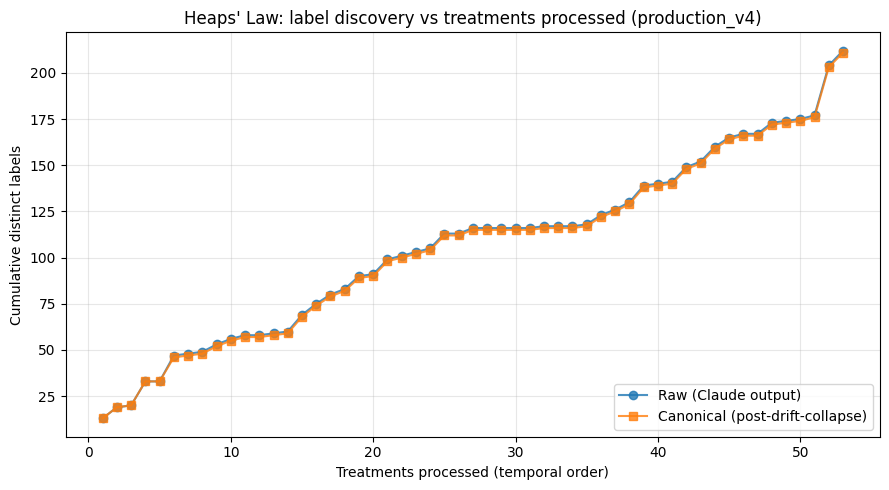

In [5]:
def cumulative_distinct_curve(
    treatment_order: List[Tuple[str, str]],
    first_seen: Dict[str, str],
) -> Tuple[List[int], List[int]]:
    """Return (x, y) for the Heaps' Law curve.

    x = treatments processed (1-indexed)
    y = cumulative distinct labels seen by that treatment
    """
    # Group labels by their first-seen treatment via timestamp.
    ts_to_labels = defaultdict(list)
    for label, ts in first_seen.items():
        ts_to_labels[ts].append(label)
    xs, ys = [], []
    seen = 0
    for i, (_tid, ts) in enumerate(treatment_order, start=1):
        # Any label whose first-seen-at == this treatment's ts
        # counts as discovered at this step.
        seen += len(ts_to_labels.get(ts, []))
        xs.append(i)
        ys.append(seen)
    return xs, ys


xs_raw, ys_raw = cumulative_distinct_curve(treatment_order, raw_first_seen)
xs_can, ys_can = cumulative_distinct_curve(treatment_order, canonical_first_seen)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(xs_raw, ys_raw, 'o-', label='Raw (Claude output)', alpha=0.8)
ax.plot(xs_can, ys_can, 's-', label='Canonical (post-drift-collapse)', alpha=0.8)
ax.set_xlabel('Treatments processed (temporal order)')
ax.set_ylabel('Cumulative distinct labels')
ax.set_title(f"Heaps' Law: label discovery vs treatments processed ({EXPERIMENT})")
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Growth statistics

Two numbers worth tracking:

- **Slope at endpoint** — new labels per treatment in the most
  recent run.  If high, we're still discovering; if near 0, the
  vocabulary has plateaued for this corpus.
- **Drift ratio** — `1 - canonical/raw`.  How much of the
  apparent vocabulary growth is LLM normalization noise vs real
  new features.  High = canonicalization step is urgent.

In [6]:
def endpoint_slope(xs: List[int], ys: List[int], window: int = 10) -> float:
    """Slope of the last `window` treatments, in new-labels-per-treatment."""
    if len(xs) < 2:
        return 0.0
    k = min(window, len(xs))
    dx = xs[-1] - xs[-k]
    dy = ys[-1] - ys[-k]
    if dx == 0:
        return 0.0
    return dy / dx


def avg_labels_per_treatment(
    annotations: List[Dict[str, Any]],
    label_canonicalizer: Optional[Dict[str, str]] = None,
) -> float:
    """Distinct labels per treatment, averaged over all treatments."""
    per_treatment = defaultdict(set)
    for ann in annotations:
        tid = ann.get('treatment_id')
        label = ann.get('feature_label')
        if not tid or not label:
            continue
        if label_canonicalizer is not None:
            label = label_canonicalizer.get(label, label)
        per_treatment[tid].add(label)
    if not per_treatment:
        return 0.0
    return sum(len(s) for s in per_treatment.values()) / len(per_treatment)


def print_growth_stats() -> None:
    print(f'Treatments processed: {len(treatment_order)}')
    print(f'')
    print(f'  RAW vocabulary')
    print(f'    Distinct labels (cumulative): {len(raw_first_seen)}')
    print(f'    Avg labels per treatment:     {avg_labels_per_treatment(annotations):.1f}')
    print(f'    Endpoint slope (last 10):     {endpoint_slope(xs_raw, ys_raw):.2f} new/treatment')
    print(f'')
    print(f'  CANONICAL vocabulary')
    print(f'    Distinct labels (cumulative): {len(canonical_first_seen)}')
    print(f'    Avg labels per treatment:     {avg_labels_per_treatment(annotations, canonicalization):.1f}')
    print(f'    Endpoint slope (last 10):     {endpoint_slope(xs_can, ys_can):.2f} new/treatment')
    print(f'')
    if raw_first_seen and canonical_first_seen:
        drift = 1 - (len(canonical_first_seen) / len(raw_first_seen))
        print(f'  Drift fraction (raw → canonical): {drift:.1%}')
        if drift > 0.2:
            print('    ↑ HIGH — label canonicalization is urgent before scaling up')
        elif drift > 0.05:
            print('    moderate — canonicalize when convenient')
        else:
            print('    low — drift is not contributing much to vocabulary growth')


print_growth_stats()

Treatments processed: 53

  RAW vocabulary
    Distinct labels (cumulative): 212
    Avg labels per treatment:     9.2
    Endpoint slope (last 10):     5.78 new/treatment

  CANONICAL vocabulary
    Distinct labels (cumulative): 211
    Avg labels per treatment:     9.2
    Endpoint slope (last 10):     5.78 new/treatment

  Drift fraction (raw → canonical): 0.5%
    low — drift is not contributing much to vocabulary growth


## Hand-reviewed vocabulary

After a brat-review round, the `features_hand` DB carries the
labels the reviewer actually kept (plus anything they added).
Three comparisons against the bootstrap output:

- **Vocabulary size**: how many distinct labels survived review,
  raw and canonical.
- **Reviewer disagreement**: what fraction of bootstrap labels
  were rejected.  High = bootstrap prompt needs work.
- **Reviewer additions**: what fraction of final labels were
  invented by the reviewer (not in any Claude output).
  High = bootstrap missed important features.

In [7]:
if not hand_annotations:
    print('No features_hand DB yet — run bin/brat_ingest after a brat review.')
else:
    # Scope the comparison to treatments that have BOTH a candidate
    # and a hand annotation.  Without this scoping, 'rejected' would
    # include every label from every UN-reviewed treatment in the
    # candidate DB — which isn't rejection, just deferred review.
    # Under the correct scoping, 'rejected' means: 'a label the
    # reviewer saw during hand-review and chose not to keep.'
    reviewed_tids = {
        a['treatment_id']
        for a in hand_annotations
        if 'treatment_id' in a
    }
    scoped_candidate = [
        a for a in annotations
        if a.get('treatment_id') in reviewed_tids
    ]

    candidate_labels_all = {a['feature_label'] for a in annotations}
    candidate_labels = {a['feature_label'] for a in scoped_candidate}
    hand_labels = {a['feature_label'] for a in hand_annotations}
    canon_candidate = {canonicalization.get(l, l) for l in candidate_labels}
    canon_hand = {canonicalization.get(l, l) for l in hand_labels}

    # Reviewer actions breakdown via the reviewer_action field
    # (kept / added; deleted annotations don't appear in features_hand).
    action_counts = Counter(
        a.get('reviewer_action', 'unknown') for a in hand_annotations
    )

    all_tids = {
        a['treatment_id']
        for a in annotations
        if 'treatment_id' in a
    }
    print(
        f'Treatments: {len(reviewed_tids)} reviewed / '
        f'{len(all_tids)} total in candidate DB '
        f'({len(all_tids - reviewed_tids)} awaiting review)'
    )
    print()
    print('Vocabulary — scoped to REVIEWED treatments only')
    print(f'  Candidate (raw, reviewed only):     {len(candidate_labels)}')
    print(f'  Candidate (canonical, reviewed):    {len(canon_candidate)}')
    print(f'  Hand (raw):                         {len(hand_labels)}')
    print(f'  Hand (canonical):                   {len(canon_hand)}')
    print()
    print(
        f'For context: candidate has {len(candidate_labels_all)} '
        f'raw labels total across all treatments; the extras '
        f'({len(candidate_labels_all - candidate_labels)}) come from '
        f'unreviewed treatments and are not evaluated here.'
    )
    print()
    print('Reviewer actions on bootstrap annotations')
    for action, n in action_counts.most_common():
        print(f'  {action:<10} {n}')

    # Labels the reviewer added that Claude never produced (scoped
    # to reviewed treatments so this is honest).
    reviewer_only = canon_hand - canon_candidate
    # Labels Claude produced (in reviewed treatments) that the
    # reviewer kept zero of.  Real reviewer signal now.
    reviewer_rejected = canon_candidate - canon_hand
    print()
    print(
        f'Reviewer-only labels (Claude missed): {len(reviewer_only)}'
    )
    if reviewer_only:
        for lbl in sorted(reviewer_only):
            print(f'  + {lbl}')
    print(
        f'Rejected labels (Claude wrong, in reviewed treatments): '
        f'{len(reviewer_rejected)}'
    )
    if reviewer_rejected:
        for lbl in sorted(reviewer_rejected):
            print(f'  − {lbl}')

Treatments: 5 reviewed / 53 total in candidate DB (48 awaiting review)

Vocabulary — scoped to REVIEWED treatments only
  Candidate (raw, reviewed only):     46
  Candidate (canonical, reviewed):    45
  Hand (raw):                         46
  Hand (canonical):                   45

For context: candidate has 212 raw labels total across all treatments; the extras (166) come from unreviewed treatments and are not evaluated here.

Reviewer actions on bootstrap annotations
  kept       81
  added      7

Reviewer-only labels (Claude missed): 0
Rejected labels (Claude wrong, in reviewed treatments): 0


## Cost and performance (from `metrics` sub-doc)

The `bin/llm_annotate_features` instrumentation captures:

- `wall_clock_seconds` / `api_latency_seconds` — where time went
- `input_tokens` / `output_tokens` — measured cost basis
- `synth_doc_chars` — input-size predictor
- `complexity_score` — pre-computed predictor for annotation count

If most cells here show "no data", run a fresh bootstrap pass —
status docs from before the instrumentation landed don't carry
the `metrics` sub-dict.

In [8]:
metrics_rows = [
    d for d in status_docs if d.get('metrics')
]
print(f'{len(metrics_rows)}/{len(status_docs)} status docs carry metrics.')
if not metrics_rows:
    print('Run `bin/llm_annotate_features --experiment {} --force ...`'
          ' to regenerate with instrumentation.'.format(EXPERIMENT))

56/56 status docs carry metrics.


In [9]:
# Pull metrics into arrays for plotting.  Filter on presence
# rather than truthiness — 0.0 / 0 are legitimate values.
def col(rows, key):
    return [r['metrics'].get(key) for r in rows]


synth_chars = col(metrics_rows, 'synth_doc_chars')
api_latency = col(metrics_rows, 'api_latency_seconds')
wall_clock = col(metrics_rows, 'wall_clock_seconds')
input_tokens = col(metrics_rows, 'input_tokens')
output_tokens = col(metrics_rows, 'output_tokens')
complexity = col(metrics_rows, 'complexity_score')

# Defensive: drop any None entries before computing arrays.
def clean_pair(xs, ys):
    return [
        (x, y) for x, y in zip(xs, ys)
        if x is not None and y is not None
    ]


# Cost calibration: measured vs estimated output tokens.
if metrics_rows:
    in_out = [
        (i, o) for i, o in zip(input_tokens, output_tokens)
        if i is not None and o is not None
    ]
    if in_out:
        in_arr = np.array([p[0] for p in in_out])
        out_arr = np.array([p[1] for p in in_out])
        ratio = float(out_arr.mean() / in_arr.mean())
        print(f'Measured output/input token ratio (mean): {ratio:.2%}')
        print(f'  (the cost estimator assumes 25% — adjust if this differs significantly)')

Measured output/input token ratio (mean): 52.02%
  (the cost estimator assumes 25% — adjust if this differs significantly)


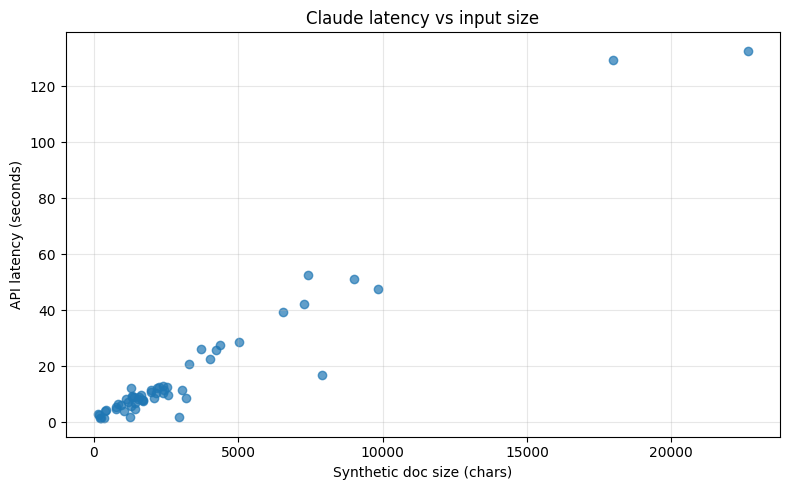

In [10]:
# Wall-clock vs synth-doc-chars (does longer input → longer call?)
pairs = clean_pair(synth_chars, api_latency)
if pairs:
    xs = [p[0] for p in pairs]
    ys = [p[1] for p in pairs]
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.scatter(xs, ys, alpha=0.7)
    ax.set_xlabel('Synthetic doc size (chars)')
    ax.set_ylabel('API latency (seconds)')
    ax.set_title('Claude latency vs input size')
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print('Not enough instrumented runs yet.')

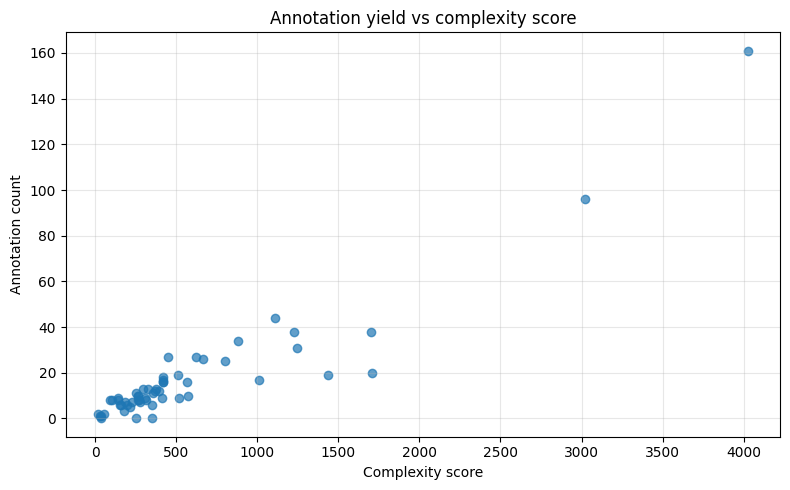

In [11]:
# Complexity score vs annotation count — does the complexity
# scorer predict how many features Claude will find?
if metrics_rows:
    annotation_count_by_tid = {
        d['treatment_id']: d.get('annotation_count', 0)
        for d in status_docs
    }
    pairs = [
        (d['metrics']['complexity_score'],
         annotation_count_by_tid.get(d['treatment_id'], 0))
        for d in metrics_rows
        if d['metrics'].get('complexity_score') is not None
    ]
    if pairs:
        xs = [p[0] for p in pairs]
        ys = [p[1] for p in pairs]
        fig, ax = plt.subplots(figsize=(8, 5))
        ax.scatter(xs, ys, alpha=0.7)
        ax.set_xlabel('Complexity score')
        ax.set_ylabel('Annotation count')
        ax.set_title('Annotation yield vs complexity score')
        ax.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()

## Next steps

- **If raw curve is still steep at the end**: more treatments
  will keep producing new labels.  Either run more bootstrap
  (if drift is low) or canonicalize first (if drift fraction
  was high above).
- **If canonical curve has plateaued**: the bootstrap is done
  discovering.  Bottleneck is review labor, not coverage.
- **If reviewer-only labels are common**: bootstrap prompt is
  missing concepts; tweak the seed.
- **If reviewer rejection is common**: bootstrap is too eager;
  tweak the prompt to be more conservative.

Re-export the canonicalization mapping after each review round:

```bash
# Manual: open the annotation.conf from bin/brat_export, eyeball
# drift entries, add them to docs/feature_label_canonicalization.json.
```

## Multi-species merge detection: term-repetition metric

Real single-species treatments concentrate their technical
vocabulary within specific sections (one Pileus block, one
Stipe block, etc.), so each anatomical term appears a handful
of times.  Multi-species merged treatments (§6 in the data
quality memo) repeat the same section structure N times, so
each anatomical term gets N-fold boosted.

Metric: `n_terms_above_k` — count of distinct non-stop-word
terms appearing at least K times in the description+diagnosis
text.

Hypothesis: this metric correlates with the annotation count
that Claude produced.  If it does, a threshold on the metric
can be applied BEFORE the bootstrap pass to skip suspected
merges and save API budget.


In [12]:
from collections import Counter
import re

# Compact English stop-word list (avoids the NLTK dependency).
# Domain-specific additions come next: common mycology
# measurement units and structural markers that would confound
# the technical-term-repetition signal.
_STOP_WORDS = {
    "the", "of", "and", "in", "to", "or", "with", "on", "at",
    "by", "an", "as", "is", "are", "was", "were", "be", "been",
    "being", "not", "no", "this", "that", "these", "those", "it",
    "its", "for", "from", "up", "down", "into", "out", "over",
    "under", "after", "before", "then", "than", "so", "such",
    "which", "when", "where", "who", "how", "what", "why",
    "some", "any", "all", "each", "every", "one", "two", "three",
    "four", "five", "more", "most", "less", "least", "very",
    "much", "many", "few", "also", "both", "either", "neither",
    "if", "but", "however", "although", "though", "while",
    "have", "has", "had", "having", "may", "might", "can",
    "could", "would", "should", "shall", "will", "do", "does",
    "did", "done", "there", "their", "them", "they", "he",
    "she", "his", "her", "him",
    # Domain-specific: measurement / structural noise.
    "mm", "cm", "um", "nm", "ul", "kpa", "wide", "long", "high",
    "thick", "diam", "diameter", "size", "cell", "cells",
    "wall", "walls", "base", "apex", "surface",
}
_TOKEN_RE = re.compile(r"[a-zA-Z]{3,}")


def n_terms_above_k(text, k=5, stop=None):
    """Number of distinct non-stop-word terms appearing >= k times."""
    stop = stop or _STOP_WORDS
    tokens = _TOKEN_RE.findall(text.lower())
    counts = Counter(t for t in tokens if t not in stop)
    return sum(1 for c in counts.values() if c >= k)


def top_terms(text, n=20, stop=None):
    """Top-n non-stop-word terms by frequency, as (term, count)."""
    stop = stop or _STOP_WORDS
    tokens = _TOKEN_RE.findall(text.lower())
    counts = Counter(t for t in tokens if t not in stop)
    return counts.most_common(n)


# Load treatments_prose docs for every treatment we have status
# info for.  Batch by _id from the status docs to avoid scanning
# all 81k docs.
treatments_db = server[f"skol_exp_{EXPERIMENT}_02_00_treatments_prose"]
tids = sorted(d["treatment_id"] for d in status_docs)

metric_rows = []
for tid in tids:
    try:
        doc = treatments_db[tid]
    except Exception:
        continue
    text = " ".join(
        (doc.get(f) or "") for f in ("description", "diagnosis")
    )
    if not text.strip():
        continue
    metric_rows.append({
        "treatment_id": tid,
        "text": text,
        "n_terms_above_5": n_terms_above_k(text, k=5),
        "text_length": len(text),
    })

# Cross-reference with annotation counts from status docs.
_ann_count = {
    d["treatment_id"]: d.get("annotation_count", 0)
    for d in status_docs
}
for row in metric_rows:
    row["annotation_count"] = _ann_count.get(row["treatment_id"], 0)

print(f"Computed metric for {len(metric_rows)} treatments")


Computed metric for 56 treatments


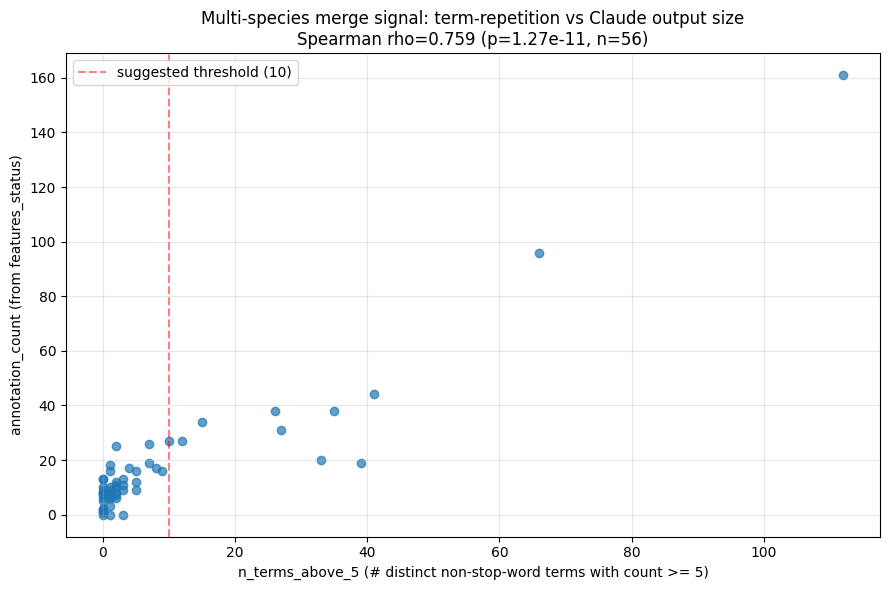

Threshold at n_terms_above_5 >= 10:
  above: 11 treatments, annotation_count avg 48.6, max 161
  below: 45 treatments, annotation_count avg 9.5, max 26


In [13]:
from scipy.stats import spearmanr

xs = [r["n_terms_above_5"] for r in metric_rows]
ys = [r["annotation_count"] for r in metric_rows]

rho, p = spearmanr(xs, ys)

fig, ax = plt.subplots(figsize=(9, 6))
ax.scatter(xs, ys, alpha=0.7)
ax.set_xlabel("n_terms_above_5 (# distinct non-stop-word terms with count >= 5)")
ax.set_ylabel("annotation_count (from features_status)")
ax.set_title(
    f"Multi-species merge signal: term-repetition vs Claude output size\n"
    f"Spearman rho={rho:.3f} (p={p:.3g}, n={len(xs)})"
)
ax.grid(True, alpha=0.3)

# Highlight the suggested threshold at n_terms_above_5 = 10 for
# visual reference.
ax.axvline(10, color="red", linestyle="--", alpha=0.5,
           label="suggested threshold (10)")
ax.legend(loc="upper left")
plt.tight_layout()
plt.show()

# What annotation-count range does the threshold predict?
above = [r for r in metric_rows if r["n_terms_above_5"] >= 10]
below = [r for r in metric_rows if r["n_terms_above_5"] < 10]
print(f"Threshold at n_terms_above_5 >= 10:")
print(f"  above: {len(above)} treatments, "
      f"annotation_count avg {sum(r['annotation_count'] for r in above) / max(1, len(above)):.1f}, "
      f"max {max((r['annotation_count'] for r in above), default=0)}")
print(f"  below: {len(below)} treatments, "
      f"annotation_count avg {sum(r['annotation_count'] for r in below) / max(1, len(below)):.1f}, "
      f"max {max((r['annotation_count'] for r in below), default=0)}")


In [14]:
# Show the top-20 non-stop terms for the highest-metric treatments
# so the operator can eyeball whether the signal is picking up
# repeated-section-structure vs some other noise.
top_by_metric = sorted(
    metric_rows, key=lambda r: r["n_terms_above_5"], reverse=True,
)[:5]

for row in top_by_metric:
    print(f"treatment_id: {row['treatment_id']}")
    print(f"  n_terms_above_5: {row['n_terms_above_5']}, "
          f"annotation_count: {row['annotation_count']}, "
          f"text_length: {row['text_length']} chars")
    print(f"  top 20 non-stop terms:")
    for term, cnt in top_terms(row["text"], n=20):
        print(f"    {cnt:>4}  {term}")
    print()


treatment_id: taxon_592128a80445cd6dd355fbcfeca82266dc2a6796dd9d05003ad819fc91327213
  n_terms_above_5: 112, annotation_count: 161, text_length: 22594 chars
  top 20 non-stop terms:
      44  margin
      37  pileus
      37  broad
      34  stipe
      34  hyphae
      31  white
      27  buff
      25  odor
      24  dry
      23  disc
      22  becoming
      22  taste
      21  color
      21  age
      21  lamellae
      19  fibrillose
      19  context
      19  trama
      18  decurrent
      18  pinkish

treatment_id: taxon_572d470e955a515d2a42157eca330cd00ebc54f489f15d45be38b595f2986ee7
  n_terms_above_5: 66, annotation_count: 96, text_length: 17936 chars
  top 20 non-stop terms:
      18  pale
      15  first
      15  hyaline
      13  rather
      13  spore
      13  violet
      12  thin
      12  spores
      11  asci
      11  pigment
      10  paraphyses
      10  clusters
      10  ascospores
       9  smooth
       9  saccobolus
       9  arc
       8  excipulum
     